# Load Dataset

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np

In [3]:
columns = ['price', 'date_of_transfer', 'postcode',
    'property_type', 'old_new', 'duration', 'paon', 'saon',
    'street', 'locality', 'town_city', 'district', 'county',
    'ppd_category_type', 'record_status']



df = pd.read_csv('/content/drive/MyDrive/Internship BCC/pp-complete.csv' ,header=None,names=columns)
df.head()

,price,date_of_transfer,postcode,property_type,old_new,duration,paon,saon,street,locality,town_city,district,county,ppd_category_type,record_status
0,36995,1995-03-24 00:00,SE19 3NF,F,N,L,CROWN POINT,14,BEULAH HILL,Unnamed: 10,LONDON,CROYDON,GREATER LONDON,A,A.1
1,25000,1995-03-31 00:00,E16 1LG,F,N,L,9,NaN,POLLARD CLOSE,NaN,LONDON,NEWHAM,GREATER LONDON,A,A
2,25500,1995-05-17 00:00,EN3 6EA,F,N,L,33,NaN,BRIDLE CLOSE,NaN,ENFIELD,ENFIELD,GREATER LONDON,A,A
3,42000,1995-04-21 00:00,N13 4RS,T,N,L,87,NaN,RUSSELL ROAD,NaN,LONDON,ENFIELD,GREATER LONDON,A,A
4,43000,1995-06-30 00:00,RM10 7NU,T,N,F,45,NaN,BOSWORTH ROAD,NaN,DAGENHAM,BARKING AND DAGENHAM,GREATER LONDON,A,A


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31004536 entries, 0 to 31004535
Data columns (total 15 columns):
 #   Column             Dtype 
---  ------             ----- 
 0   price              int64 
 1   date_of_transfer   object
 2   postcode           object
 3   property_type      object
 4   old_new            object
 5   duration           object
 6   paon               object
 7   saon               object
 8   street             object
 9   locality           object
 10  town_city          object
 11  district           object
 12  county             object
 13  ppd_category_type  object
 14  record_status      object
dtypes: int64(1), object(14)
memory usage: 3.5+ GB


In [5]:
df_pop = pd.read_csv('/content/drive/MyDrive/Internship BCC/ONS Data For Population 2024.csv')
display(df_pop)
df_pop.info()

,LAD25CD,Name,Geography,Area (sq km),Estimated Population mid-2024,2024 people per sq. km
0,K04000001,ENGLAND AND WALES,Country,"151,047","61,806,682",409
1,E92000001,ENGLAND,Country,"130,310","58,620,101",450
2,E12000001,NORTH EAST,Region,"8,581","2,760,678",322
3,E06000047,County Durham,Unitary Authority,"2,226","538,011",242
4,E06000005,Darlington,Unitary Authority,197,"112,489",570
...,...,...,...,...,...,...
352,W06000018,Caerphilly,Unitary Authority,277,"176,865",638
353,W06000019,Blaenau Gwent,Unitary Authority,109,"67,873",624
354,W06000020,Torfaen,Unitary Authority,126,"94,119",749
355,W06000021,Monmouthshire,Unitary Authority,849,"94,930",112


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 6 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   LAD25CD                        357 non-null    object
 1   Name                           357 non-null    object
 2   Geography                      357 non-null    object
 3   Area (sq km)                   357 non-null    object
 4   Estimated Population mid-2024  357 non-null    object
 5   2024 people per sq. km         357 non-null    object
dtypes: object(6)
memory usage: 16.9+ KB


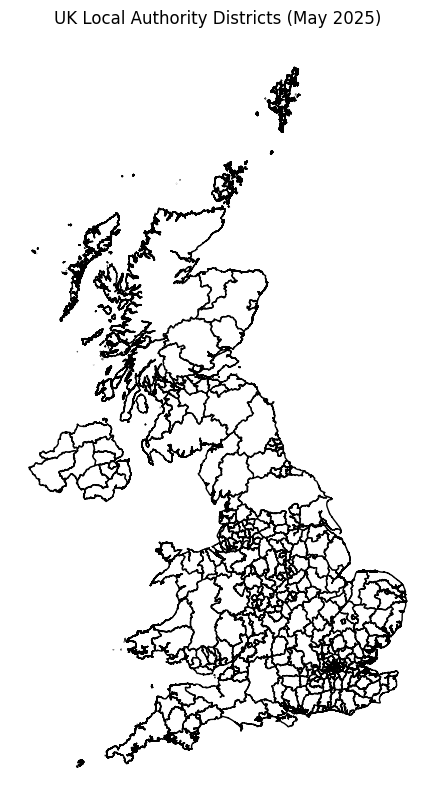

In [6]:
import geopandas as gpd
import matplotlib.pyplot as plt

path = '/content/drive/MyDrive/Internship BCC/LAD_MAY_2025_UK_BFC_V2_-5497827781037142926.geojson'
lad = gpd.read_file(path)

fig, ax = plt.subplots(figsize=(10,10))
lad.plot(ax=ax, edgecolor="black", color="white")
ax.set_axis_off()

plt.title("UK Local Authority Districts (May 2025)")
plt.show()

# Data Cleaning

#### Data for the main DataFrame

In [7]:
cat_cols = [
    "property_type",
    "old_new",
    "duration",
    "town_city",
    "district",
    "county",
    "ppd_category_type"
]

for col in cat_cols:
    df[col] = df[col].astype("category")

In [8]:
df.isnull().sum()

,0
price,0
date_of_transfer,0
postcode,49659
property_type,0
old_new,0
duration,0
paon,4184
saon,27298414
street,493169
locality,11770026


In [9]:
df["date_of_transfer"] = pd.to_datetime(df["date_of_transfer"])
df = df.drop(columns=["saon", "paon", "locality", "record_status"])
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31004536 entries, 0 to 31004535
Data columns (total 11 columns):
 #   Column             Dtype         
---  ------             -----         
 0   price              int64         
 1   date_of_transfer   datetime64[ns]
 2   postcode           object        
 3   property_type      category      
 4   old_new            category      
 5   duration           category      
 6   street             object        
 7   town_city          category      
 8   district           category      
 9   county             category      
 10  ppd_category_type  category      
dtypes: category(7), datetime64[ns](1), int64(1), object(2)
memory usage: 1.2+ GB


In [10]:
df.nunique()

,0
price,279172
date_of_transfer,11347
postcode,1331571
property_type,5
old_new,2
duration,3
street,336202
town_city,1173
district,467
county,132


In [11]:
#checking unique value for some of the columns
col_check = ['property_type', 'duration', 'town_city', 'district', 'county', 'ppd_category_type']

for col in col_check:
    print(f"{col}: {df[col].unique()}")

property_type: ['F', 'T', 'S', 'D', 'O']
Categories (5, object): ['D', 'F', 'O', 'S', 'T']
duration: ['L', 'F', 'U']
Categories (3, object): ['F', 'L', 'U']
town_city: ['LONDON', 'ENFIELD', 'DAGENHAM', 'BURNLEY', 'CROYDON', ..., 'THORNHILL', 'BILLINGHURST', 'GATWICK', 'BIGGAR', 'HADDINGTON']
Length: 1173
Categories (1173, object): ['ABBOTS LANGLEY', 'ABERAERON', 'ABERDARE', 'ABERDOVEY', ..., 'YELVERTON',
                            'YEOVIL', 'YORK', 'YSTRAD MEURIG']
district: ['CROYDON', 'NEWHAM', 'ENFIELD', 'BARKING AND DAGENHAM', 'BURNLEY', ..., 'CUMBERLAND', 'BRYHER', 'WEST SUFFOLK', 'ISLES OF SCILLY', 'ST MARTIN'S']
Length: 467
Categories (467, object): ['ABERCONWY', 'ADUR', 'ALLERDALE', 'ALNWICK', ..., 'WYRE', 'WYRE FOREST',
                           'YNYS MON-ISLE OF ANGLESEY', 'YORK']
county: ['GREATER LONDON', 'LANCASHIRE', 'WEST YORKSHIRE', 'KENT', 'NORTHAMPTONSHIRE', ..., 'WEST NORTHAMPTONSHIRE', 'WREKIN', 'NORTH NORTHAMPTONSHIRE', 'WESTMORLAND AND FURNESS', 'CUMBERLAND']
Le

In April of 2023, The UK Goverment reorganized how district are in some areas. So, with that in mind, we decide to remap all the previous district to be in line with the current one

Source: https://blog.planningportal.co.uk/2023/03/24/local-authority-changes-from-1-april-2023/


In [12]:
district_map = {
    'ALLERDALE': 'CUMBERLAND',
    'CARLISLE': 'CUMBERLAND',
    'COPELAND': 'CUMBERLAND',

    'BARROW-IN-FURNESS': 'WESTMORLAND AND FURNESS',
    'EDEN': 'WESTMORLAND AND FURNESS',
    'SOUTH LAKELAND': 'WESTMORLAND AND FURNESS',

    'CRAVEN': 'NORTH YORKSHIRE',
    'HAMBLETON': 'NORTH YORKSHIRE',
    'HARROGATE': 'NORTH YORKSHIRE',
    'RICHMONDSHIRE': 'NORTH YORKSHIRE',
    'RYEDALE': 'NORTH YORKSHIRE',
    'SCARBOROUGH': 'NORTH YORKSHIRE',
    'SELBY': 'NORTH YORKSHIRE',

    'MENDIP': 'SOMERSET',
    'SEDGEMOOR': 'SOMERSET',
    'SOMERSET WEST AND TAUNTON': 'SOMERSET',
    'SOUTH SOMERSET': 'SOMERSET'
}

df = df.copy()
df['district'] = df['district'].replace(district_map)

/tmp/ipykernel_275/148962204.py:25: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df['district'] = df['district'].replace(district_map)


In [13]:
df['year'] = df['date_of_transfer'].dt.year
df = df[df['year'] >= 2022]
display(df.head())
df.info()

,price,date_of_transfer,postcode,property_type,old_new,duration,street,town_city,district,county,ppd_category_type,year
27375256,280000,2022-06-06,B78 3XA,D,N,F,WESTMORLAND CLOSE,TAMWORTH,TAMWORTH,STAFFORDSHIRE,A,2022
27375257,312500,2022-06-20,ST7 4JZ,D,N,F,SANDS ROAD,STOKE-ON-TRENT,NEWCASTLE-UNDER-LYME,STAFFORDSHIRE,A,2022
27375258,150000,2022-06-30,ST14 7QG,S,N,F,LAMBERT ROAD,UTTOXETER,EAST STAFFORDSHIRE,STAFFORDSHIRE,A,2022
27375259,515000,2022-05-25,B78 3UG,D,N,F,MOAT DRIVE,TAMWORTH,LICHFIELD,STAFFORDSHIRE,A,2022
27375260,262500,2022-07-15,ST20 0HY,D,N,F,HOLLIES BROOK CLOSE,STAFFORD,STAFFORD,STAFFORDSHIRE,A,2022


<class 'pandas.core.frame.DataFrame'>
Index: 3629280 entries, 27375256 to 31004535
Data columns (total 12 columns):
 #   Column             Dtype         
---  ------             -----         
 0   price              int64         
 1   date_of_transfer   datetime64[ns]
 2   postcode           object        
 3   property_type      category      
 4   old_new            category      
 5   duration           category      
 6   street             object        
 7   town_city          category      
 8   district           category      
 9   county             category      
 10  ppd_category_type  category      
 11  year               int32         
dtypes: category(7), datetime64[ns](1), int32(1), int64(1), object(2)
memory usage: 187.0+ MB


#### Data for Population

In [14]:
df_pop.columns

Index(['LAD25CD', 'Name', 'Geography', 'Area (sq km)',
       'Estimated Population mid-2024', '2024 people per sq. km'],
      dtype='object')

In [15]:
df_pop["Geography"] = df_pop["Geography"].astype("category")

In [16]:
df_pop = df_pop[df_pop["Geography"].isin([
    "Unitary Authority",
    "Metropolitan District",
    "London Borough",
    "Non-metropolitan District"
])]

In [17]:
num_cols = ["Area (sq km)", "Estimated Population mid-2024", "2024 people per sq. km"]

In [18]:
for cols in num_cols:
    df_pop[cols] = df_pop[cols].str.replace(",", "")
df_pop[num_cols] = df_pop[num_cols].apply(pd.to_numeric)

In [19]:
df_pop["Name"] = df_pop["Name"].str.upper()
df["district"] = df["district"].str.upper()

In [20]:
df_pop.info()

<class 'pandas.core.frame.DataFrame'>
Index: 318 entries, 3 to 356
Data columns (total 6 columns):
 #   Column                         Non-Null Count  Dtype   
---  ------                         --------------  -----   
 0   LAD25CD                        318 non-null    object  
 1   Name                           318 non-null    object  
 2   Geography                      318 non-null    category
 3   Area (sq km)                   318 non-null    int64   
 4   Estimated Population mid-2024  318 non-null    int64   
 5   2024 people per sq. km         318 non-null    int64   
dtypes: category(1), int64(3), object(2)
memory usage: 15.6+ KB


In [21]:
df_pop = df_pop.rename(columns={ "Name" : "district"})

In [22]:
df_pop

,LAD25CD,district,Geography,Area (sq km),Estimated Population mid-2024,2024 people per sq. km
3,E06000047,COUNTY DURHAM,Unitary Authority,2226,538011,242
4,E06000005,DARLINGTON,Unitary Authority,197,112489,570
5,E06000001,HARTLEPOOL,Unitary Authority,94,98180,1048
6,E06000002,MIDDLESBROUGH,Unitary Authority,54,156161,2898
7,E06000057,NORTHUMBERLAND,Unitary Authority,5020,331420,66
...,...,...,...,...,...,...
352,W06000018,CAERPHILLY,Unitary Authority,277,176865,638
353,W06000019,BLAENAU GWENT,Unitary Authority,109,67873,624
354,W06000020,TORFAEN,Unitary Authority,126,94119,749
355,W06000021,MONMOUTHSHIRE,Unitary Authority,849,94930,112


In [23]:
df_merged = df.merge(
    df_pop[["district", "Area (sq km)", "Estimated Population mid-2024", "2024 people per sq. km"]],
    on="district",
    how="left"
)

In [24]:
df_merged

,price,date_of_transfer,postcode,property_type,old_new,duration,street,town_city,district,county,ppd_category_type,year,Area (sq km),Estimated Population mid-2024,2024 people per sq. km
0,280000,2022-06-06,B78 3XA,D,N,F,WESTMORLAND CLOSE,TAMWORTH,TAMWORTH,STAFFORDSHIRE,A,2022,31.0,81117.0,2630.0
1,312500,2022-06-20,ST7 4JZ,D,N,F,SANDS ROAD,STOKE-ON-TRENT,NEWCASTLE-UNDER-LYME,STAFFORDSHIRE,A,2022,211.0,127727.0,605.0
2,150000,2022-06-30,ST14 7QG,S,N,F,LAMBERT ROAD,UTTOXETER,EAST STAFFORDSHIRE,STAFFORDSHIRE,A,2022,387.0,129659.0,335.0
3,515000,2022-05-25,B78 3UG,D,N,F,MOAT DRIVE,TAMWORTH,LICHFIELD,STAFFORDSHIRE,A,2022,331.0,111932.0,338.0
4,262500,2022-07-15,ST20 0HY,D,N,F,HOLLIES BROOK CLOSE,STAFFORD,STAFFORD,STAFFORDSHIRE,A,2022,598.0,141556.0,237.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3629275,875000,2026-01-15,RG41 4XJ,D,N,F,JAPONICA CLOSE,WOKINGHAM,WOKINGHAM,WOKINGHAM,A,2026,179.0,187200.0,1046.0
3629276,370000,2026-01-14,RG20 6QQ,T,N,F,MEADOW CLOSE,NEWBURY,WEST BERKSHIRE,WEST BERKSHIRE,A,2026,704.0,165112.0,234.0
3629277,700000,2026-01-15,SL3 9NQ,S,N,F,FAIRFIELD AVENUE,SLOUGH,WINDSOR AND MAIDENHEAD,WINDSOR AND MAIDENHEAD,A,2026,196.0,158943.0,809.0
3629278,283000,2026-01-16,GU47 0ZB,T,N,F,STUBBS FOLLY,SANDHURST,BRACKNELL FOREST,BRACKNELL FOREST,A,2026,109.0,130806.0,1196.0


Applying Urban Rural Area Type Based on this

Source: https://ec.europa.eu/eurostat/statistics-explained/SEPDF/cache/28569.pdf


In [25]:
df_merged["area_type"] = df_merged["2024 people per sq. km"].apply(
    lambda x: "Urban" if x >= 300 else "Rural"
)

In [26]:
df_merged

,price,date_of_transfer,postcode,property_type,old_new,duration,street,town_city,district,county,ppd_category_type,year,Area (sq km),Estimated Population mid-2024,2024 people per sq. km,area_type
0,280000,2022-06-06,B78 3XA,D,N,F,WESTMORLAND CLOSE,TAMWORTH,TAMWORTH,STAFFORDSHIRE,A,2022,31.0,81117.0,2630.0,Urban
1,312500,2022-06-20,ST7 4JZ,D,N,F,SANDS ROAD,STOKE-ON-TRENT,NEWCASTLE-UNDER-LYME,STAFFORDSHIRE,A,2022,211.0,127727.0,605.0,Urban
2,150000,2022-06-30,ST14 7QG,S,N,F,LAMBERT ROAD,UTTOXETER,EAST STAFFORDSHIRE,STAFFORDSHIRE,A,2022,387.0,129659.0,335.0,Urban
3,515000,2022-05-25,B78 3UG,D,N,F,MOAT DRIVE,TAMWORTH,LICHFIELD,STAFFORDSHIRE,A,2022,331.0,111932.0,338.0,Urban
4,262500,2022-07-15,ST20 0HY,D,N,F,HOLLIES BROOK CLOSE,STAFFORD,STAFFORD,STAFFORDSHIRE,A,2022,598.0,141556.0,237.0,Rural
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3629275,875000,2026-01-15,RG41 4XJ,D,N,F,JAPONICA CLOSE,WOKINGHAM,WOKINGHAM,WOKINGHAM,A,2026,179.0,187200.0,1046.0,Urban
3629276,370000,2026-01-14,RG20 6QQ,T,N,F,MEADOW CLOSE,NEWBURY,WEST BERKSHIRE,WEST BERKSHIRE,A,2026,704.0,165112.0,234.0,Rural
3629277,700000,2026-01-15,SL3 9NQ,S,N,F,FAIRFIELD AVENUE,SLOUGH,WINDSOR AND MAIDENHEAD,WINDSOR AND MAIDENHEAD,A,2026,196.0,158943.0,809.0,Urban
3629278,283000,2026-01-16,GU47 0ZB,T,N,F,STUBBS FOLLY,SANDHURST,BRACKNELL FOREST,BRACKNELL FOREST,A,2026,109.0,130806.0,1196.0,Urban


In [46]:
df_merged.to_csv('df_merged.csv', index=False)

In [3]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt

In [4]:
df_merged = pd.read_csv('/content/drive/MyDrive/Internship BCC/df_merged.csv')
display(df_merged)

,price,date_of_transfer,postcode,property_type,old_new,duration,street,town_city,district,county,ppd_category_type,year,Area (sq km),Estimated Population mid-2024,2024 people per sq. km,area_type
0,280000,2022-06-06,B78 3XA,D,N,F,WESTMORLAND CLOSE,TAMWORTH,TAMWORTH,STAFFORDSHIRE,A,2022,31.0,81117.0,2630.0,Urban
1,312500,2022-06-20,ST7 4JZ,D,N,F,SANDS ROAD,STOKE-ON-TRENT,NEWCASTLE-UNDER-LYME,STAFFORDSHIRE,A,2022,211.0,127727.0,605.0,Urban
2,150000,2022-06-30,ST14 7QG,S,N,F,LAMBERT ROAD,UTTOXETER,EAST STAFFORDSHIRE,STAFFORDSHIRE,A,2022,387.0,129659.0,335.0,Urban
3,515000,2022-05-25,B78 3UG,D,N,F,MOAT DRIVE,TAMWORTH,LICHFIELD,STAFFORDSHIRE,A,2022,331.0,111932.0,338.0,Urban
4,262500,2022-07-15,ST20 0HY,D,N,F,HOLLIES BROOK CLOSE,STAFFORD,STAFFORD,STAFFORDSHIRE,A,2022,598.0,141556.0,237.0,Rural
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3629275,875000,2026-01-15,RG41 4XJ,D,N,F,JAPONICA CLOSE,WOKINGHAM,WOKINGHAM,WOKINGHAM,A,2026,179.0,187200.0,1046.0,Urban
3629276,370000,2026-01-14,RG20 6QQ,T,N,F,MEADOW CLOSE,NEWBURY,WEST BERKSHIRE,WEST BERKSHIRE,A,2026,704.0,165112.0,234.0,Rural
3629277,700000,2026-01-15,SL3 9NQ,S,N,F,FAIRFIELD AVENUE,SLOUGH,WINDSOR AND MAIDENHEAD,WINDSOR AND MAIDENHEAD,A,2026,196.0,158943.0,809.0,Urban
3629278,283000,2026-01-16,GU47 0ZB,T,N,F,STUBBS FOLLY,SANDHURST,BRACKNELL FOREST,BRACKNELL FOREST,A,2026,109.0,130806.0,1196.0,Urban


#### District Table

In [27]:
df['district'].value_counts()


,count
district,
BIRMINGHAM,49578
LEEDS,47850
NORTH YORKSHIRE,47151
COUNTY DURHAM,40018
CORNWALL,39375
...,...
OADBY AND WIGSTON,3401
MERTHYR TYDFIL,3082
RUTLAND,2642


In [5]:
district_counts = df_merged['district'].value_counts()

valid_districts = district_counts[district_counts > 3].index.tolist()

df_merged = df_merged[df_merged['district'].isin(valid_districts)]

In [6]:
df_median_district_yearly = df_merged.groupby(['district', 'year','area_type'])['price'].median().reset_index()
display(df_median_district_yearly)

,district,year,area_type,price
0,ADUR,2022,Urban,380000.0
1,ADUR,2023,Urban,375000.0
2,ADUR,2024,Urban,362000.0
3,ADUR,2025,Urban,375000.0
4,ADUR,2026,Urban,364775.0
...,...,...,...,...
1584,YORK,2022,Urban,300000.0
1585,YORK,2023,Urban,299997.5
1586,YORK,2024,Urban,300000.0
1587,YORK,2025,Urban,300000.0


In [7]:
df_yearly_cleaned = df_median_district_yearly[df_median_district_yearly['district'].isin(valid_districts)]

display(df_yearly_cleaned)
df_yearly_cleaned.info()

,district,year,area_type,price
0,ADUR,2022,Urban,380000.0
1,ADUR,2023,Urban,375000.0
2,ADUR,2024,Urban,362000.0
3,ADUR,2025,Urban,375000.0
4,ADUR,2026,Urban,364775.0
...,...,...,...,...
1584,YORK,2022,Urban,300000.0
1585,YORK,2023,Urban,299997.5
1586,YORK,2024,Urban,300000.0
1587,YORK,2025,Urban,300000.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1589 entries, 0 to 1588
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   district   1589 non-null   object 
 1   year       1589 non-null   int64  
 2   area_type  1589 non-null   object 
 3   price      1589 non-null   float64
dtypes: float64(1), int64(1), object(2)
memory usage: 49.8+ KB


In [31]:
df_yearly_cleaned.isnull().sum()

,0
district,0
year,0
area_type,0
price,0


In [8]:
dr_yearly_cleaned = df_yearly_cleaned.sort_values(
    ['district', 'year']
)

In [9]:
def calc_cagr(group):

    prices = group['price'].dropna()

    if len(prices) < 2:
        return None

    start_price = prices.iloc[0]
    end_price = prices.iloc[-1]

    years = group['year'].max() - group['year'].min()

    cagr = (end_price / start_price) ** (1 / years) - 1

    return cagr * 100

In [10]:
cagr_district = (
    df_yearly_cleaned
    .groupby(['district', 'area_type'])
    .apply(calc_cagr)
    .reset_index(name='cagr_pct')
)

/tmp/ipykernel_10903/1035124265.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(calc_cagr)


In [11]:
fastest_growth = cagr_district.sort_values(
    'cagr_pct', ascending=False
)

#### Map Filtering

In [36]:
lad.head()

,FID,LAD25CD,LAD25NM,LAD25NMW,BNG_E,BNG_N,LONG,LAT,GlobalID,geometry
0,1,E06000001,Hartlepool,,447161,531473,-1.270174,54.676132,847f2c4b-a7cf-4c71-840c-0864853246d5,"MULTIPOLYGON (((450154.6 525938.201, 450140.09..."
1,2,E06000002,Middlesbrough,,451141,516887,-1.210998,54.544679,f1925b75-6267-417d-a77a-05cdc4c6b1b3,"MULTIPOLYGON (((446854.7 517192.7, 446854.281 ..."
2,3,E06000003,Redcar and Cleveland,,464330,519596,-1.006565,54.567520,36b1db27-3dfa-4ed6-8e81-36bf3abeeacc,"MULTIPOLYGON (((451747.397 520561.1, 451792.20..."
3,4,E06000004,Stockton-on-Tees,,444940,518179,-1.306646,54.556876,22a6adf7-e812-4c09-89b1-6753ec35de93,"MULTIPOLYGON (((447177.704 517811.797, 447176...."
4,5,E06000005,Darlington,,428029,515648,-1.568356,54.535345,309364b5-9b5c-4f9c-81f5-8a3a79699fd1,"POLYGON ((423496.602 524724.299, 423497.204 52..."


In [37]:
lad['LAD25NM'] = lad['LAD25NM'].str.upper()

In [38]:
lad

,FID,LAD25CD,LAD25NM,LAD25NMW,BNG_E,BNG_N,LONG,LAT,GlobalID,geometry
0,1,E06000001,HARTLEPOOL,,447161,531473,-1.270174,54.676132,847f2c4b-a7cf-4c71-840c-0864853246d5,"MULTIPOLYGON (((450154.6 525938.201, 450140.09..."
1,2,E06000002,MIDDLESBROUGH,,451141,516887,-1.210998,54.544679,f1925b75-6267-417d-a77a-05cdc4c6b1b3,"MULTIPOLYGON (((446854.7 517192.7, 446854.281 ..."
2,3,E06000003,REDCAR AND CLEVELAND,,464330,519596,-1.006565,54.567520,36b1db27-3dfa-4ed6-8e81-36bf3abeeacc,"MULTIPOLYGON (((451747.397 520561.1, 451792.20..."
3,4,E06000004,STOCKTON-ON-TEES,,444940,518179,-1.306646,54.556876,22a6adf7-e812-4c09-89b1-6753ec35de93,"MULTIPOLYGON (((447177.704 517811.797, 447176...."
4,5,E06000005,DARLINGTON,,428029,515648,-1.568356,54.535345,309364b5-9b5c-4f9c-81f5-8a3a79699fd1,"POLYGON ((423496.602 524724.299, 423497.204 52..."
...,...,...,...,...,...,...,...,...,...,...
356,357,W06000020,TORFAEN,Torfaen,327459,200480,-3.051019,51.698361,1c3eb529-b145-4eb7-84a6-b17ba581cbff,"POLYGON ((323898.201 211287.499, 324115.698 21..."
357,358,W06000021,MONMOUTHSHIRE,Sir Fynwy,337812,209231,-2.902806,51.778278,640aefaf-22cf-49c5-a974-b43fce5f28c9,"MULTIPOLYGON (((345897.698 180999.599, 345884...."
358,359,W06000022,NEWPORT,Casnewydd,337897,187432,-2.897690,51.582311,2cb099b7-0b64-4778-b41c-80d1cb832bae,"MULTIPOLYGON (((334186.001 192669.398, 334201...."
359,360,W06000023,POWYS,Powys,302329,273254,-3.435318,52.348639,ef0eb86c-2311-4027-9e84-1a6520f67a65,"POLYGON ((322392.901 334017.198, 322378.002 33..."


/usr/local/lib/python3.12/dist-packages/geopandas/geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


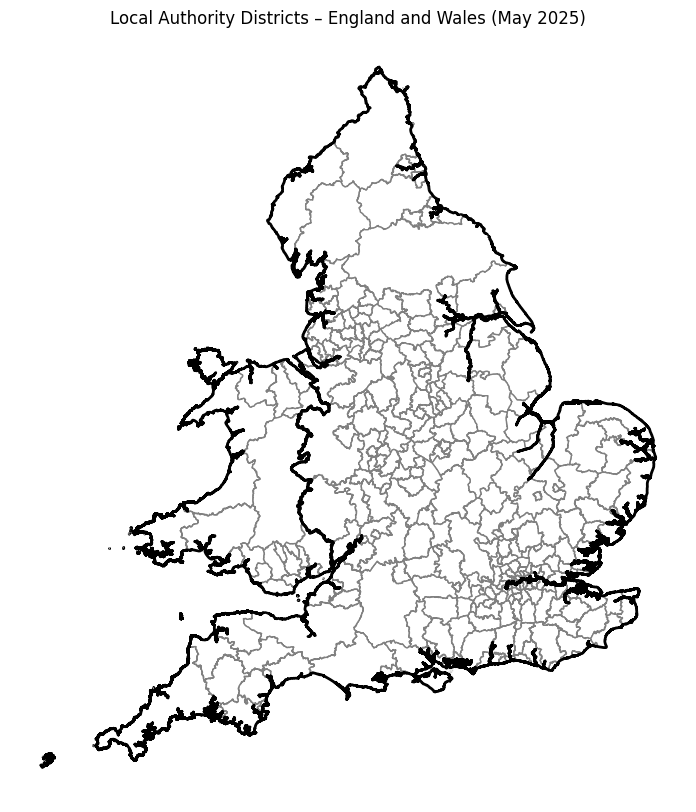

In [39]:
# Select England and Wales LADs
eng_wales = lad[lad["LAD25CD"].str.startswith(("E","W"))]

# Create a country column
eng_wales["country"] = eng_wales["LAD25CD"].str[0].map({
    "E": "England",
    "W": "Wales"
})

# Dissolve LADs into country shapes
countries = eng_wales.dissolve(by="country")

fig, ax = plt.subplots(figsize=(10,10))

# Plot LAD boundaries (thin)
eng_wales.plot(
    ax=ax,
    edgecolor="gray",
    linewidth=1,
    color="white"
)

# Plot England-Wales border (thick)
countries.boundary.plot(
    ax=ax,
    linewidth=2,
    color="black"
)

ax.set_axis_off()
plt.title("Local Authority Districts – England and Wales (May 2025)")

plt.show()

# EDA

In [40]:
fastest_growth

,district,area_type,cagr_pct
142,ISLES OF SCILLY,Rural,31.440263
277,TORFAEN,Urban,18.086129
293,WELWYN HATFIELD,Urban,9.310316
173,MOLE VALLEY,Urban,8.475657
77,DACORUM,Urban,7.336862
...,...,...,...
144,KENSINGTON AND CHELSEA,Urban,-6.389941
125,HART,Urban,-6.448413
63,CITY OF LONDON,Urban,-7.257674
67,CITY OF WESTMINSTER,Rural,-11.500069


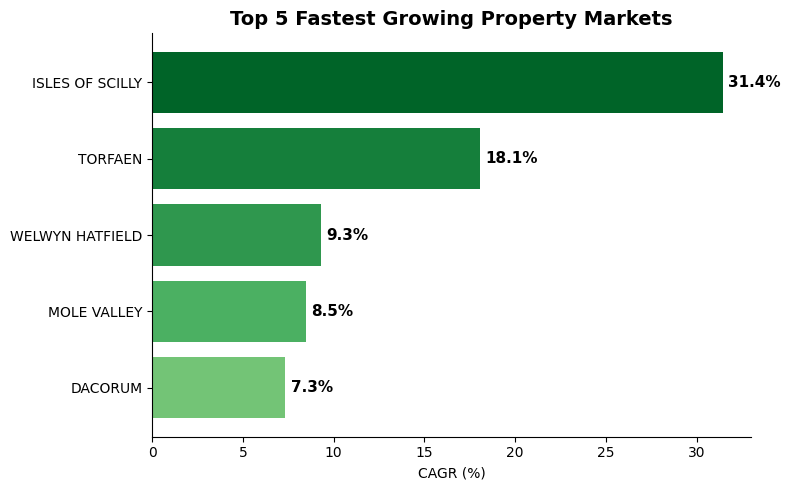

In [120]:
import matplotlib.pyplot as plt
import numpy as np

# Top 5 districts by CAGR
top5 = fastest_growth.sort_values("cagr_pct", ascending=False).head(5)

# Reverse order for leaderboard (rank 1 on top)
top5 = top5[::-1]

fig, ax = plt.subplots(figsize=(8,5))

# Green gradient colors
colors = plt.cm.Greens(np.linspace(0.5, 0.9, len(top5)))

bars = ax.barh(
    top5["district"],
    top5["cagr_pct"],
    color=colors
)

# Add CAGR labels
for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.3,
        bar.get_y() + bar.get_height()/2,
        f"{width:.1f}%",
        va="center",
        fontsize=11,
        fontweight="bold"
    )
ax.spines[['top','right']].set_visible(False)

ax.set_xlabel("CAGR (%)")
ax.set_title("Top 5 Fastest Growing Property Markets", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

/tmp/ipykernel_10903/2167335477.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"{-t:.0f}" for t in ticks])


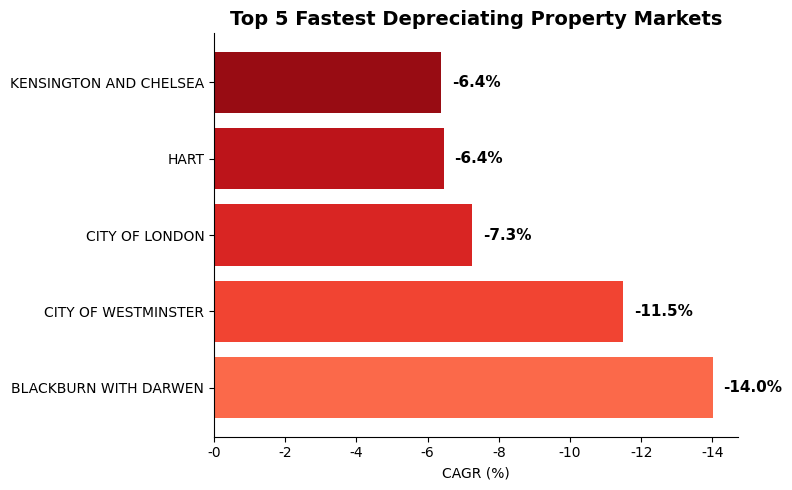

In [12]:
# Bottom 5 districts by CAGR
bot5 = fastest_growth.sort_values("cagr_pct", ascending=False).tail(5)
bot5 = bot5[::-1]

fig, ax = plt.subplots(figsize=(8,5))

colors = plt.cm.Reds(np.linspace(0.5, 0.9, len(bot5)))

# Plot absolute values so bars extend right
bars = ax.barh(
    bot5["district"],
    bot5["cagr_pct"].abs(),
    color=colors
)

# Labels showing real negative values
for bar, val in zip(bars, bot5["cagr_pct"]):
    width = bar.get_width()
    ax.text(
        width + 0.3,
        bar.get_y() + bar.get_height()/2,
        f"{val:.1f}%",
        va="center",
        fontsize=11,
        fontweight="bold"
    )

# Fix x-axis to show negative labels
ticks = ax.get_xticks()
ax.set_xticklabels([f"{-t:.0f}" for t in ticks])

ax.set_xlabel("CAGR (%)")
ax.set_title("Top 5 Fastest Depreciating Property Markets", fontsize=14, fontweight="bold")

ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

In [43]:
# Merge CAGR with LAD map
map_df = lad.merge(
    fastest_growth,
    left_on="LAD25NM",
    right_on="district",
    how="left"
)

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec

/usr/local/lib/python3.12/dist-packages/geopandas/geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


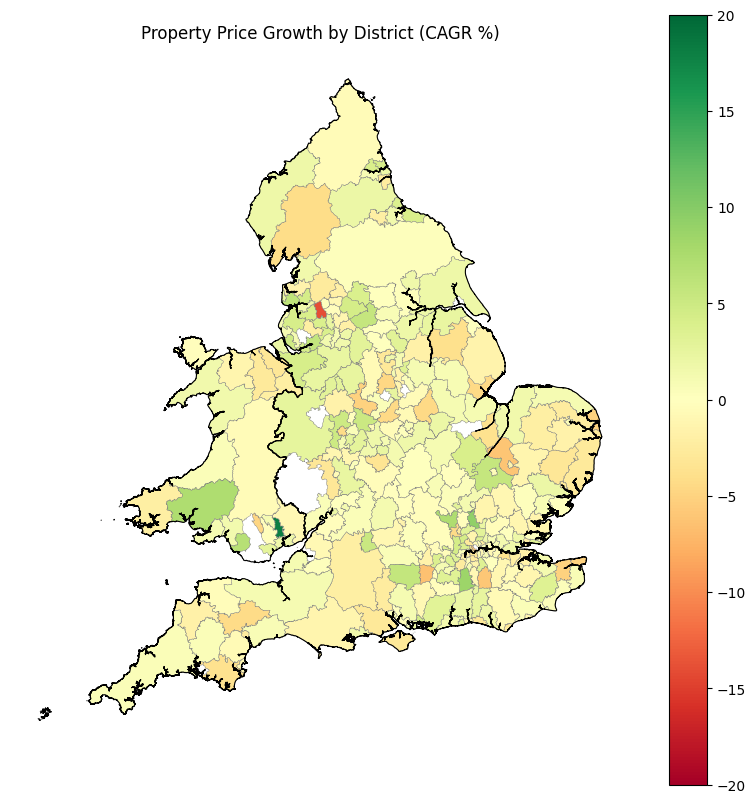

In [121]:
# England + Wales
eng_wales = map_df[map_df["LAD25CD"].str.startswith(("E","W"))]

# Country border
eng_wales["country"] = eng_wales["LAD25CD"].str[0].map({
    "E": "England",
    "W": "Wales"
})

countries = eng_wales.dissolve(by="country")

fig, ax = plt.subplots(figsize=(10,10))


# Plot LADs colored by growth
eng_wales.plot(
    column="cagr_pct",
    cmap="RdYlGn",
    legend=True,
    vmin=-20,   # minimum value for color scale (adjust if needed)
    vmax=20,    # maximum value for color scale
    edgecolor="gray",
    linewidth=0.3,
    ax=ax
)

# Thick England-Wales border
countries.boundary.plot(
    ax=ax,
    linewidth=0.8,
    color="black"
)


ax.set_axis_off()
plt.title("Property Price Growth by District (CAGR %)")

plt.show()

In [176]:
NAME_COL = "LAD25NM"

In [177]:
def get_region(keywords):
    pattern = "|".join(keywords)
    return eng_wales[eng_wales[NAME_COL].str.upper().str.contains(pattern, regex=True)]

In [179]:
def plot_region(ax, gdf, countries_gdf, title, vmin=-20, vmax=20):
    """Plot only the given GDF, tightly zoomed, with clipped country border."""
    gdf.plot(
        column="cagr_pct",
        cmap="RdYlGn",
        legend=False,
        vmin=vmin,
        vmax=vmax,
        edgecolor="gray",
        linewidth=0.4,
        missing_kwds={"color": "lightgray", "edgecolor": "gray", "label": "No data"},
        ax=ax,
    )
    # Clip country border to region bounds + small buffer
    b = gdf.total_bounds          # minx, miny, maxx, maxy
    buf = max(b[2] - b[0], b[3] - b[1]) * 0.04
    try:
        countries_gdf.cx[
            b[0] - buf : b[2] + buf,
            b[1] - buf : b[3] + buf,
        ].boundary.plot(ax=ax, linewidth=1.1, color="black")
    except Exception:
        countries_gdf.boundary.plot(ax=ax, linewidth=1.1, color="black")

    # Tight zoom to just this region
    ax.set_xlim(b[0] - buf, b[2] + buf)
    ax.set_ylim(b[1] - buf, b[3] + buf)
    ax.set_axis_off()
    ax.set_title(title, fontsize=10, fontweight="bold", pad=5)


In [178]:
# ── data ──────────────────────────────────────────────────────────────────────
eng_wales = map_df[map_df["LAD25CD"].str.startswith(("E", "W"))].copy()
eng_wales["country"] = eng_wales["LAD25CD"].str[0].map({"E": "England", "W": "Wales"})
countries = eng_wales.dissolve(by="country")

vmin, vmax = -20, 20

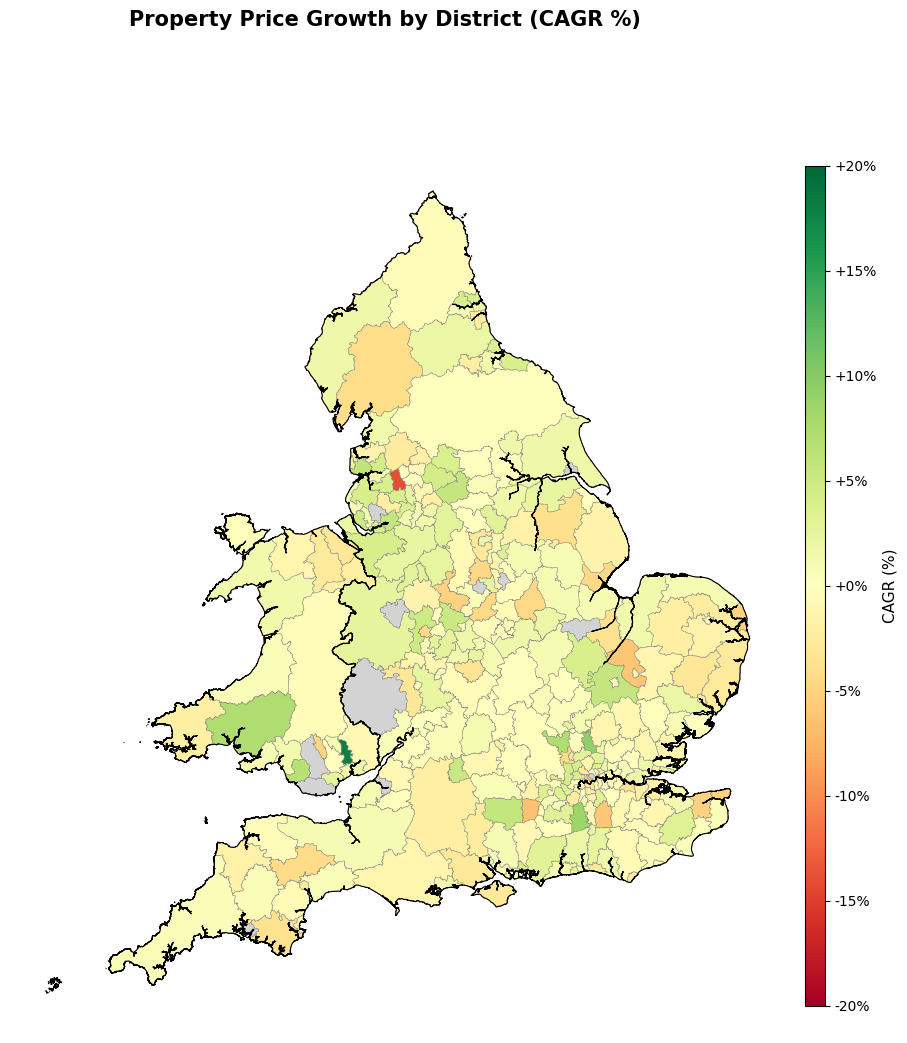

In [180]:
fig, ax_main = plt.subplots(figsize=(10, 12))
fig.suptitle("Property Price Growth by District (CAGR %)",
             fontsize=15, fontweight="bold", y=0.98)

eng_wales.plot(
    column="cagr_pct",
    cmap="RdYlGn",
    legend=False,
    vmin=vmin,
    vmax=vmax,
    edgecolor="gray",
    linewidth=0.3,
    missing_kwds={"color": "lightgray", "edgecolor": "gray", "label": "No data"},
    ax=ax_main,
)

countries.boundary.plot(ax=ax_main, linewidth=0.8, color="black")

ax_main.set_axis_off()

# ── colorbar with % labels ────────────────────────────────────────────────────
sm = cm.ScalarMappable(cmap="RdYlGn", norm=mcolors.Normalize(vmin=vmin, vmax=vmax))
sm.set_array([])

cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label("CAGR (%)", fontsize=11)
cbar.set_ticks(range(-20, 21, 5))
cbar.ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x:+.0f}%")
)

plt.show()

/tmp/ipykernel_275/4104124086.py:65: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


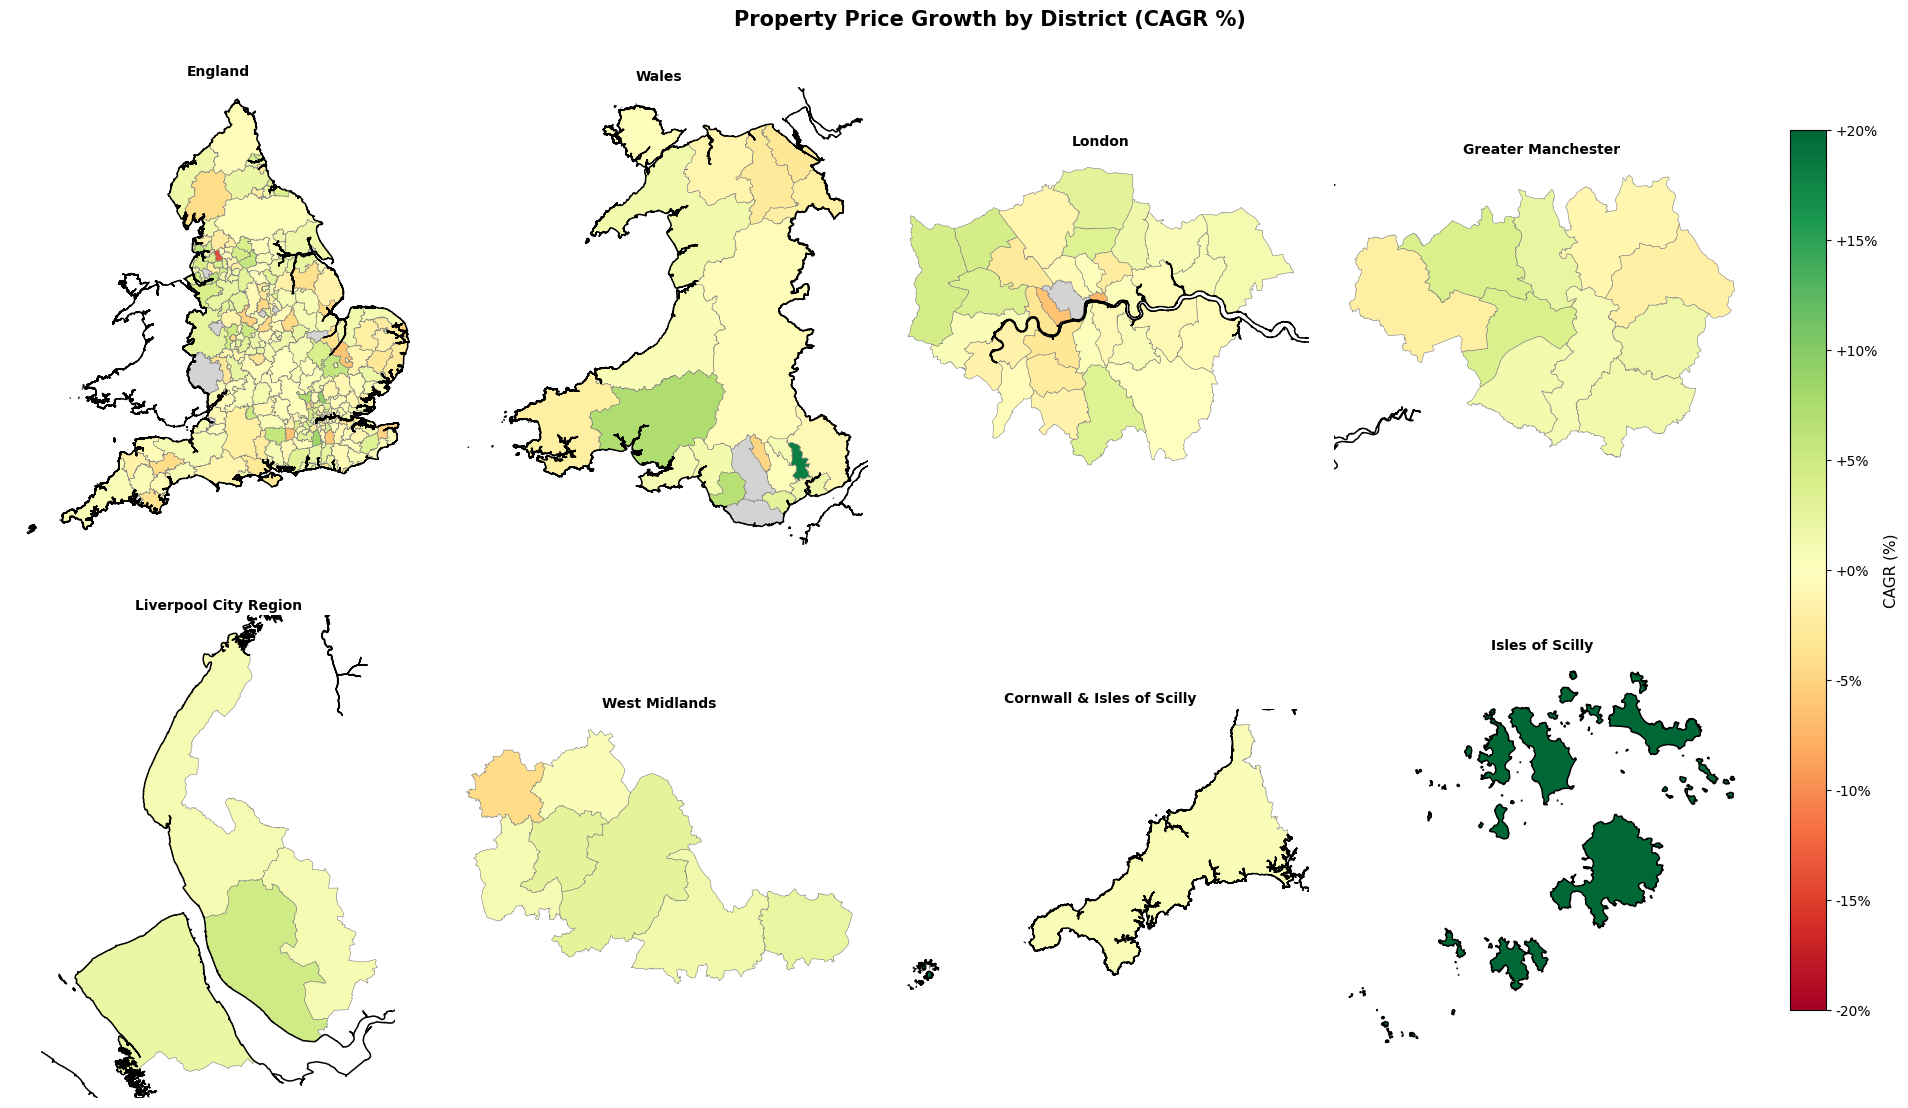

In [181]:
# ── region definitions ────────────────────────────────────────────────────────
england     = eng_wales[eng_wales["LAD25CD"].str.startswith("E")]
wales       = eng_wales[eng_wales["LAD25CD"].str.startswith("W")]
london      = eng_wales[eng_wales["LAD25CD"].str.startswith("E09")]
cornwall    = get_region(["CORNWALL", "ISLES OF SCILLY"])
manchester  = eng_wales[eng_wales["LAD25CD"].isin([
    "E08000001", "E08000002", "E08000003", "E08000004", "E08000005",
    "E08000006", "E08000007", "E08000008", "E08000009", "E08000010"
])]
liverpool   = get_region(["LIVERPOOL", "KNOWSLEY", "SEFTON", "ST HELENS", "WIRRAL"])
birmingham  = get_region(["BIRMINGHAM", "WOLVERHAMPTON", "SANDWELL", "DUDLEY",
                           "WALSALL", "SOLIHULL", "COVENTRY"])
isles = get_region(["ISLES OF SCILLY"])

regions = [
    (england,    "England"),
    (wales,      "Wales"),
    (london,     "London"),
    (manchester, "Greater Manchester"),
    (liverpool,  "Liverpool City Region"),
    (birmingham, "West Midlands"),
    (cornwall,   "Cornwall & Isles of Scilly"),
    (isles, "Isles of Scilly")
]




# ── figure: 2 rows × 4 cols (last cell = colorbar space) ─────────────────────
vmin, vmax = -20, 20
n = len(regions)   # 7
ncols = 4
nrows = 2          # 4 top + 3 bottom (last cell blank)

fig = plt.figure(figsize=(20, 11))
fig.suptitle("Property Price Growth by District (CAGR %)",
             fontsize=15, fontweight="bold", y=1.01)

gs = GridSpec(nrows, ncols, figure=fig,
              hspace=0.12, wspace=0.06,
              left=0.01, right=0.88, top=0.95, bottom=0.02)

axes = [fig.add_subplot(gs[r, c])
        for r in range(nrows) for c in range(ncols)]

for i, (ax, (gdf, title)) in enumerate(zip(axes, regions)):
    plot_region(ax, gdf, countries, title, vmin, vmax)

# Hide unused axes
for ax in axes[n:]:
    ax.set_axis_off()

# ── shared colorbar ───────────────────────────────────────────────────────────
sm = cm.ScalarMappable(cmap="RdYlGn", norm=mcolors.Normalize(vmin=vmin, vmax=vmax))
sm.set_array([])

cbar_ax = fig.add_axes([0.90, 0.10, 0.018, 0.80])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label("CAGR (%)", fontsize=11)
cbar.set_ticks(range(-20, 21, 5))
cbar.ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x:+.0f}%")
)

plt.tight_layout()
plt.show()

In [164]:
def plot_region(ax, gdf, countries_gdf, title, vmin, vmax):
    gdf.plot(
        column="price",
        cmap="viridis",
        legend=False,
        vmin=vmin,
        vmax=vmax,
        edgecolor="gray",
        linewidth=0.4,
        missing_kwds={"color": "lightgrey", "edgecolor": "gray", "label": "No data"},
        ax=ax,
    )
# Clip country border to region bounds + small buffer
    b = gdf.total_bounds          # minx, miny, maxx, maxy
    buf = max(b[2] - b[0], b[3] - b[1]) * 0.04
    try:
        countries_gdf.cx[
            b[0] - buf : b[2] + buf,
            b[1] - buf : b[3] + buf,
        ].boundary.plot(ax=ax, linewidth=1.1, color="black")
    except Exception:
        countries_gdf.boundary.plot(ax=ax, linewidth=1.1, color="black")

    # Tight zoom to just this region
    ax.set_xlim(b[0] - buf, b[2] + buf)
    ax.set_ylim(b[1] - buf, b[3] + buf)
    ax.set_axis_off()
    ax.set_title(title, fontsize=10, fontweight="bold", pad=5)


In [163]:
# ── get latest price per district ─────────────────────────────────────────────
latest_prices = (
    df_yearly_cleaned
    .sort_values("year")
    .groupby("district", as_index=False)
    .last()[["district", "price"]]
)

# ── merge with geo data ───────────────────────────────────────────────────────
# map_df uses LAD25NM as district name — normalise to upper for safe join
NAME_COL = "LAD25NM"  # change if needed

map_price = map_df.copy()
map_price["_key"] = map_price[NAME_COL].str.upper().str.strip()
latest_prices["_key"] = latest_prices["district"].str.upper().str.strip()

map_price = map_price.merge(latest_prices[["_key", "price"]], on="_key", how="left")

# ── filter England + Wales only ───────────────────────────────────────────────
eng_wales = map_price[map_price["LAD25CD"].str.startswith(("E", "W"))].copy()
eng_wales["country"] = eng_wales["LAD25CD"].str[0].map({"E": "England", "W": "Wales"})
countries = eng_wales.dissolve(by="country")

/tmp/ipykernel_275/2513203980.py:69: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


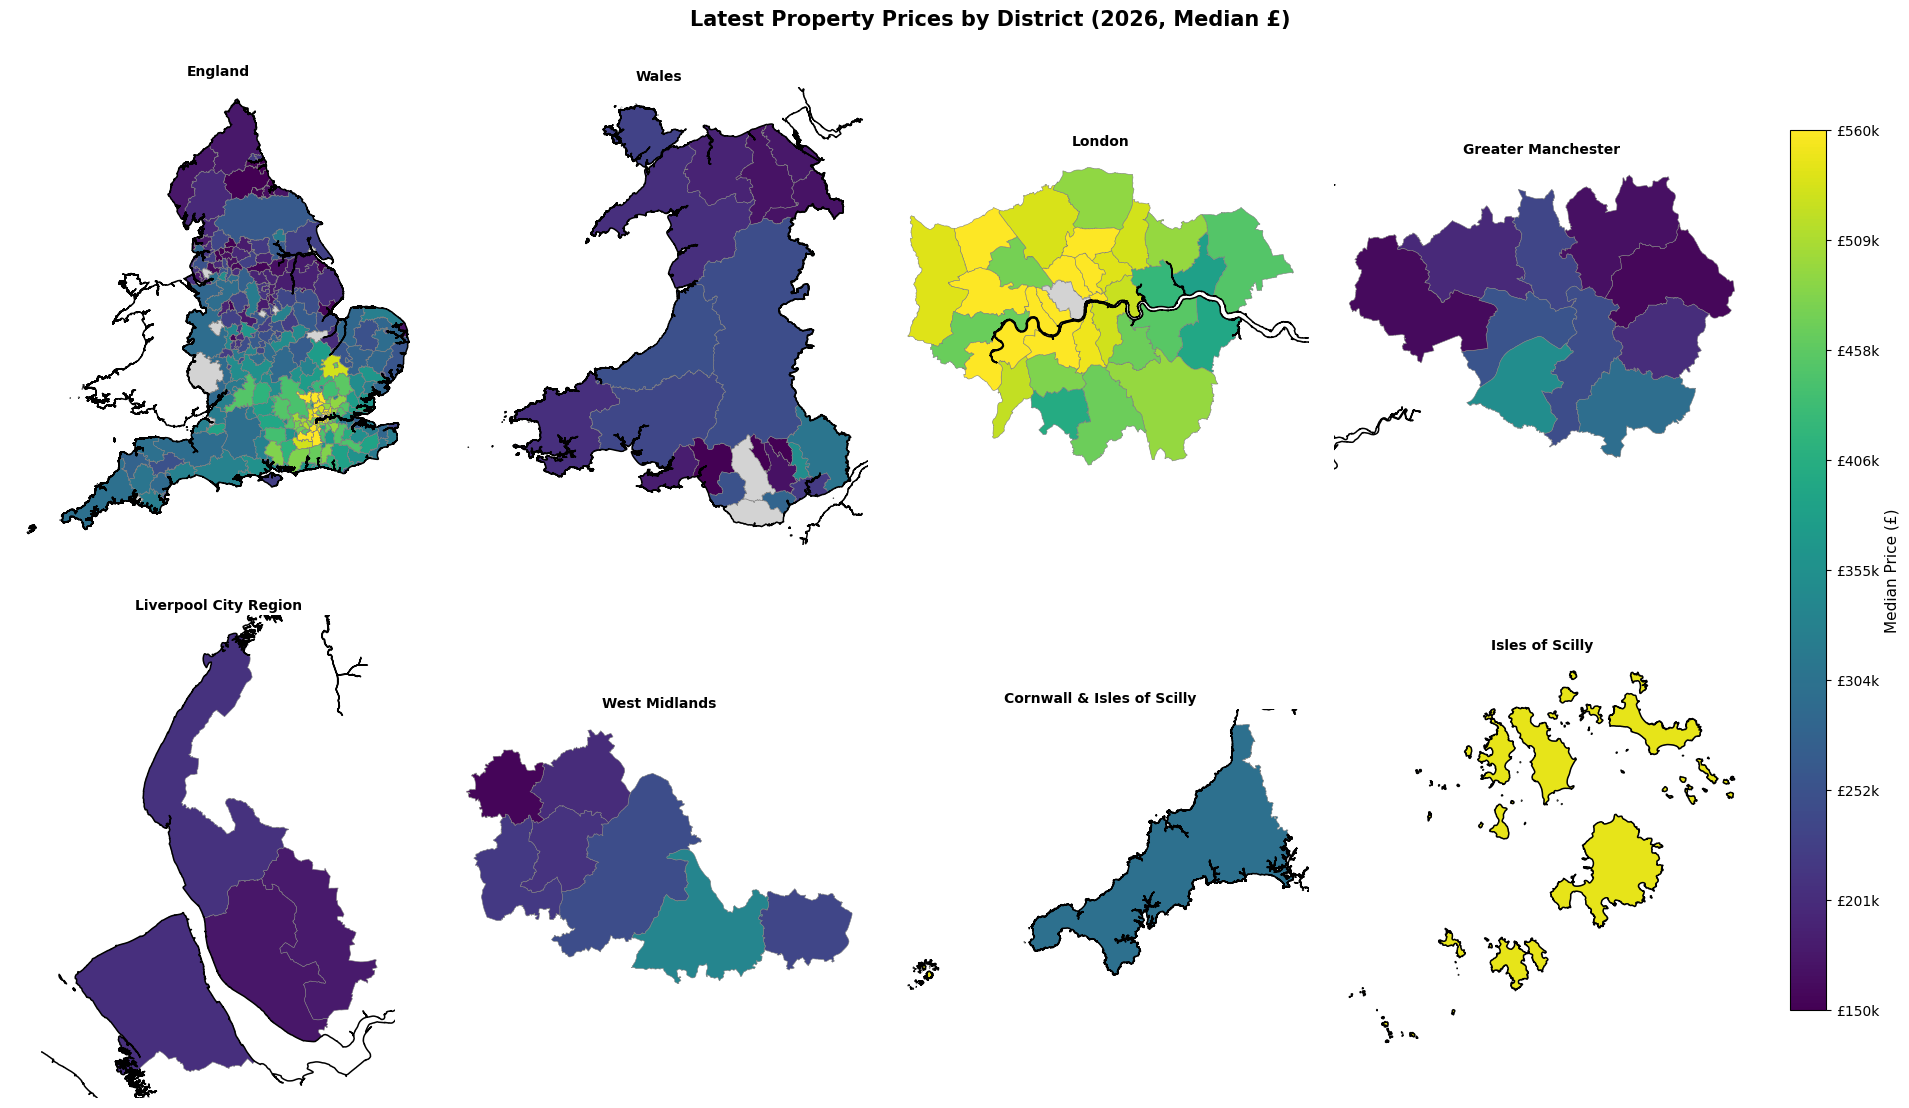

In [166]:
# ── region definitions ────────────────────────────────────────────────────────
def get_region(keywords):
    pattern = "|".join(keywords)
    return eng_wales[eng_wales[NAME_COL].str.upper().str.contains(pattern, regex=True)]

england    = eng_wales[eng_wales["LAD25CD"].str.startswith("E")]
wales      = eng_wales[eng_wales["LAD25CD"].str.startswith("W")]
london     = eng_wales[eng_wales["LAD25CD"].str.startswith("E09")]
cornwall   = get_region(["CORNWALL", "ISLES OF SCILLY"])
manchester =  eng_wales[eng_wales["LAD25CD"].isin([
    "E08000001", "E08000002", "E08000003", "E08000004", "E08000005",
    "E08000006", "E08000007", "E08000008", "E08000009", "E08000010"
])]
liverpool  = get_region(["LIVERPOOL", "KNOWSLEY", "SEFTON", "ST HELENS", "WIRRAL"])
birmingham = get_region(["BIRMINGHAM", "WOLVERHAMPTON", "SANDWELL", "DUDLEY",
                          "WALSALL", "SOLIHULL", "COVENTRY"])
isles = get_region(["ISLES OF SCILLY"])

regions = [
    (england,    "England"),
    (wales,      "Wales"),
    (london,     "London"),
    (manchester, "Greater Manchester"),
    (liverpool,  "Liverpool City Region"),
    (birmingham, "West Midlands"),
    (cornwall,   "Cornwall & Isles of Scilly"),
    (isles, "Isles of Scilly")
]

# ── color scale: set vmin/vmax based on actual price range ───────────────────
vmin = int(eng_wales["price"].quantile(0.05) // 10000 * 10000)   # 5th pct, round down
vmax = int(eng_wales["price"].quantile(0.95) // 10000 * 10000)   # 95th pct, round up


# ── figure ────────────────────────────────────────────────────────────────────
n = len(regions)
fig = plt.figure(figsize=(20, 11))
fig.suptitle("Latest Property Prices by District (2026, Median £)",
             fontsize=15, fontweight="bold", y=1.01)

gs = GridSpec(2, 4, figure=fig,
              hspace=0.12, wspace=0.06,
              left=0.01, right=0.88, top=0.95, bottom=0.02)

axes = [fig.add_subplot(gs[r, c]) for r in range(2) for c in range(4)]

for ax, (gdf, title) in zip(axes, regions):
    plot_region(ax, gdf, countries, title, vmin, vmax)

for ax in axes[n:]:
    ax.set_axis_off()

# ── colorbar with £ labels ────────────────────────────────────────────────────
sm = cm.ScalarMappable(cmap="viridis", norm=mcolors.Normalize(vmin=vmin, vmax=vmax))
sm.set_array([])

cbar_ax = fig.add_axes([0.90, 0.10, 0.018, 0.80])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label("Median Price (£)", fontsize=11)

# Evenly spaced ticks with £k formatting
import numpy as np
ticks = np.linspace(vmin, vmax, 9)
cbar.set_ticks(ticks)
cbar.ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"£{x/1000:.0f}k")
)

plt.tight_layout()
plt.show()

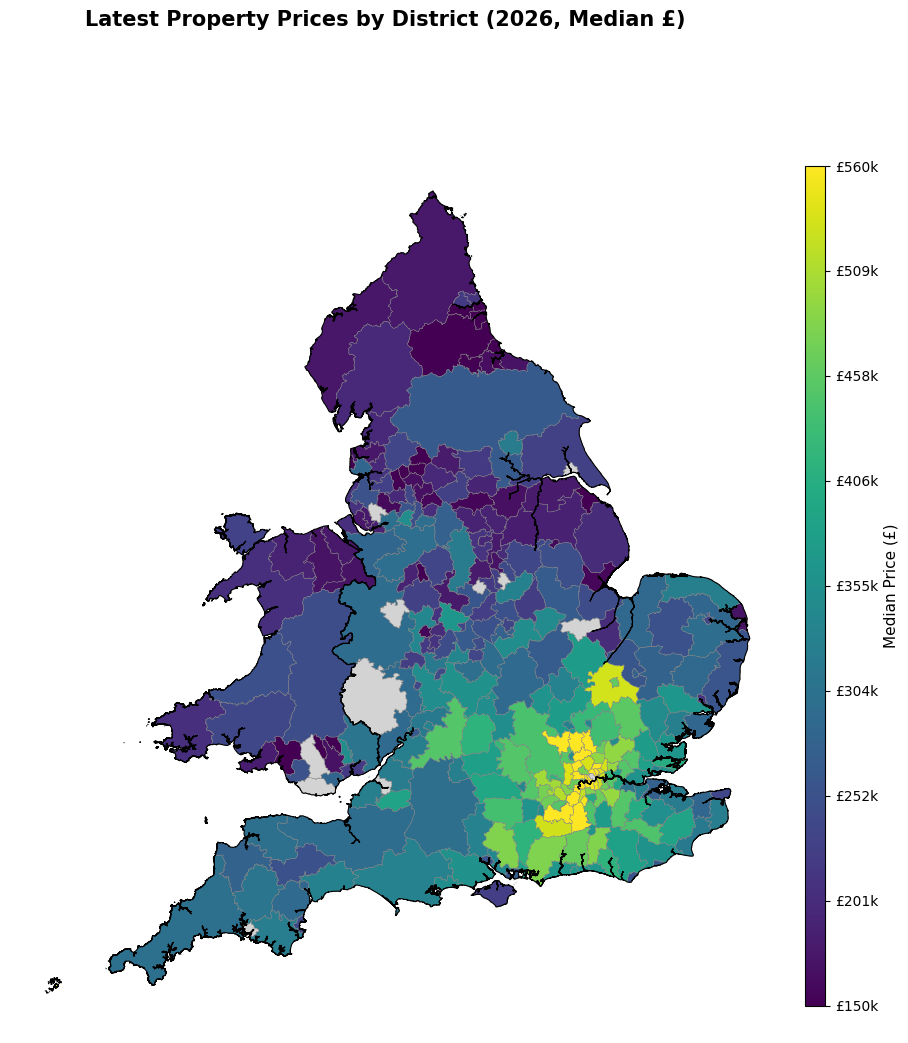

In [133]:
# ── data ──────────────────────────────────────────────────────────────────────
eng_wales = map_price[map_price["LAD25CD"].str.startswith(("E", "W"))].copy()
eng_wales["country"] = eng_wales["LAD25CD"].str[0].map({"E": "England", "W": "Wales"})
countries = eng_wales.dissolve(by="country")

vmin = int(eng_wales["price"].quantile(0.05) // 10000 * 10000)
vmax = int(eng_wales["price"].quantile(0.95) // 10000 * 10000)

# ── plot ──────────────────────────────────────────────────────────────────────
fig, ax_main = plt.subplots(figsize=(10, 12))
fig.suptitle("Latest Property Prices by District (2026, Median £)",
             fontsize=15, fontweight="bold", y=0.98)

eng_wales.plot(
    column="price",
    cmap="viridis",
    legend=False,
    vmin=vmin,
    vmax=vmax,
    edgecolor="gray",
    linewidth=0.3,
    missing_kwds={"color": "lightgrey", "edgecolor": "gray", "label": "No data"},
    ax=ax_main,
)

countries.boundary.plot(ax=ax_main, linewidth=0.8, color="black")

ax_main.set_axis_off()

# ── colorbar with £k labels ───────────────────────────────────────────────────
sm = cm.ScalarMappable(cmap="viridis", norm=mcolors.Normalize(vmin=vmin, vmax=vmax))
sm.set_array([])

cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label("Median Price (£)", fontsize=11)

import numpy as np
ticks = np.linspace(vmin, vmax, 9)
cbar.set_ticks(ticks)
cbar.ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"£{x/1000:.0f}k")
)

plt.show()

#### Are property prices higher in big urban areas compared with rural areas?

In [47]:
df_urban_rural = df_merged.groupby("area_type")["price"].agg(["count","mean","median","std"])

In [52]:
df_urban_rural

,count,mean,median,std
area_type,,,,
Rural,1108716,376268.846716,273000.0,1.478176e+06
Urban,2520564,408870.663029,285000.0,1.412356e+06


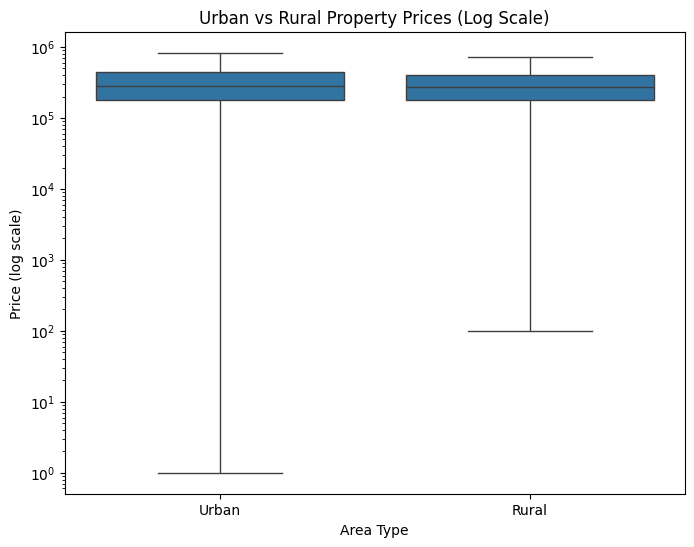

In [62]:
import seaborn as sns

plt.figure(figsize=(8,6))

sns.boxplot(
    data=df_merged,
    x="area_type",
    y="price",
    showfliers=False   # removes extreme outliers
)

plt.yscale("log")
plt.title("Urban vs Rural Property Prices (Log Scale)")
plt.ylabel("Price (log scale)")
plt.xlabel("Area Type")

plt.show()

In [54]:
from scipy.stats import ttest_ind

urban = df_merged[df_merged["area_type"]=="Urban"]["price"]
rural = df_merged[df_merged["area_type"]=="Rural"]["price"]

ttest_ind(urban, rural, equal_var=False)

TtestResult(statistic=np.float64(19.616380007372157), pvalue=np.float64(1.1412302614473492e-85), df=np.float64(2033697.6404776499))

In [55]:
df_merged["2024 people per sq. km"].corr(df_merged["price"])

np.float64(0.08585427195543016)

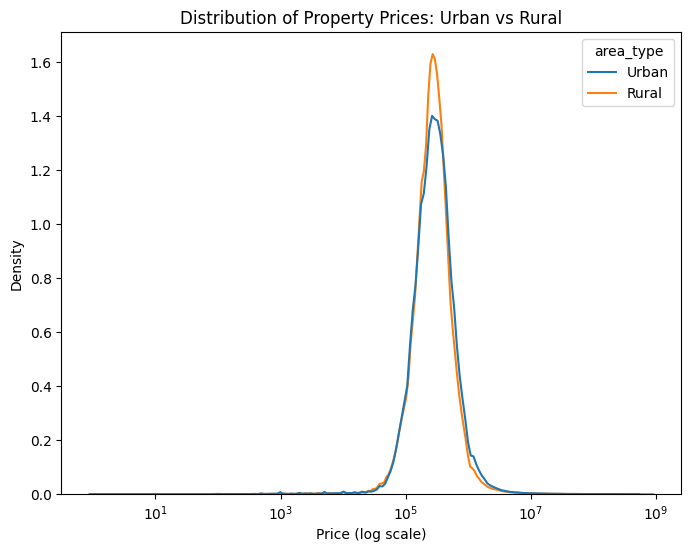

In [95]:
plt.figure(figsize=(8,6))

sns.kdeplot(
    data=df_merged,
    x="price",
    hue="area_type",
    log_scale=True,
    common_norm=False
)

plt.title("Distribution of Property Prices: Urban vs Rural")
plt.xlabel("Price (log scale)")

plt.show()

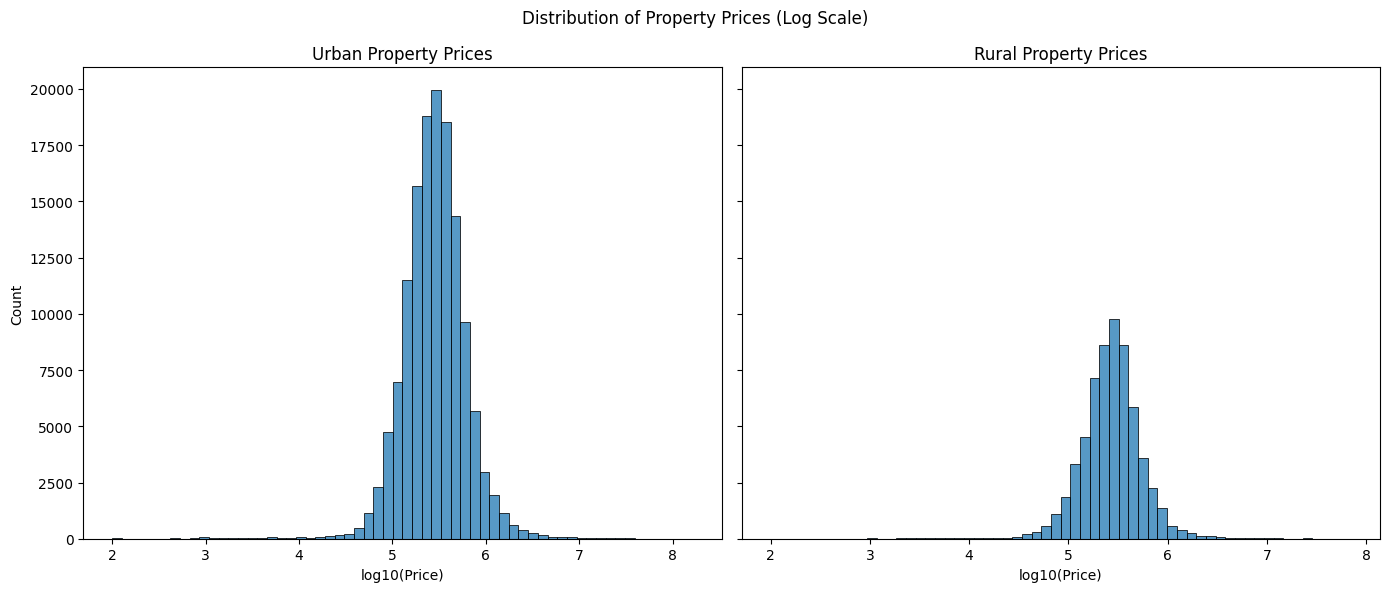

In [97]:
import numpy as np

# sample for performance
sample = df_merged.sample(200000)

# log transform price
sample["log_price"] = np.log10(sample["price"])

fig, axes = plt.subplots(1, 2, figsize=(14,6), sharey=True)

sns.histplot(sample[sample["area_type"]=="Urban"]["log_price"],
             bins=60,
             ax=axes[0])

axes[0].set_title("Urban Property Prices")
axes[0].set_xlabel("log10(Price)")
axes[0].set_ylabel("Count")

sns.histplot(sample[sample["area_type"]=="Rural"]["log_price"],
             bins=60,
             ax=axes[1])

axes[1].set_title("Rural Property Prices")
axes[1].set_xlabel("log10(Price)")

plt.suptitle("Distribution of Property Prices (Log Scale)")
plt.tight_layout()
plt.show()

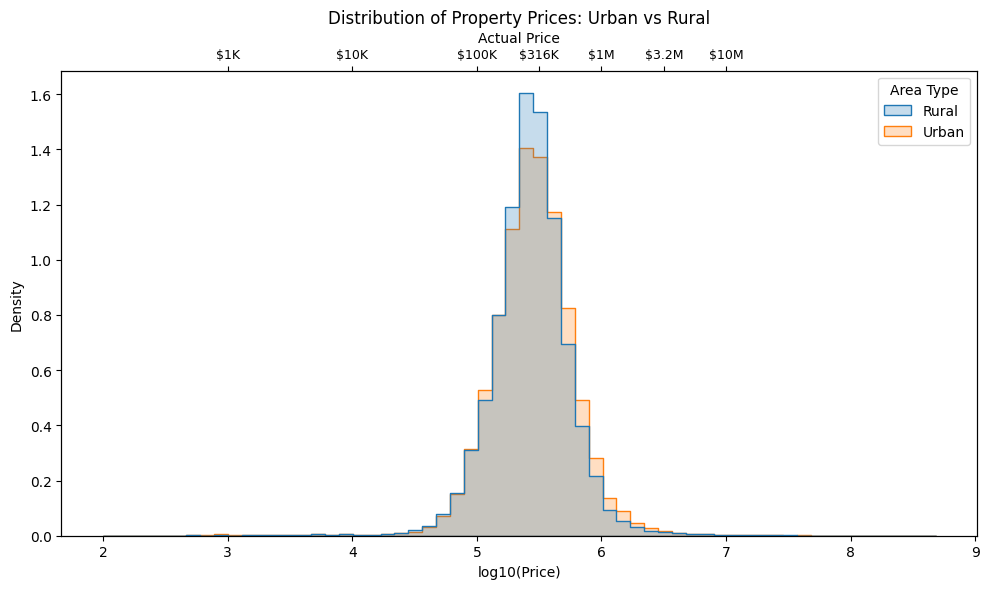

In [118]:
sample = df_merged.sample(400000)
sample["log_price"] = np.log10(sample["price"])

fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(
    data=sample,
    x="log_price",
    hue="area_type",
    bins=60,
    element="step",
    stat="density",
    common_norm=False,
    ax=ax,
)

ax.set_title("Distribution of Property Prices: Urban vs Rural")
ax.set_xlabel("log10(Price)")
ax.set_ylabel("Density")
ax.get_legend().set_title("Area Type")

# Add actual price labels on top x-axis
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
ax2.set_xticks([3, 4, 5, 5.5, 6, 6.5, 7])
ax2.set_xticklabels(["$1K", "$10K", "$100K", "$316K", "$1M", "$3.2M", "$10M"], fontsize=9)
ax2.set_xlabel("Actual Price", fontsize=10)

plt.tight_layout()
plt.show()

In [77]:
type_map = {
    "D": "Detached",
    "S": "Semi-Detached",
    "T": "Terraced",
    "F": "Flat",
    "O": "Other"
}

df_merged["property_name"] = df_merged["property_type"].map(type_map)

df_merged["area_property"] = (
    df_merged["area_type"].astype(str) + " - " +
    df_merged["property_name"].astype(str)
)

In [78]:
summary = (
    df_merged
    .groupby("area_property")["price"]
    .agg(
        entry_price=lambda x: x.quantile(0.25),
        median_price="median"
    )
    .reset_index()
)

summary = summary.sort_values("median_price")

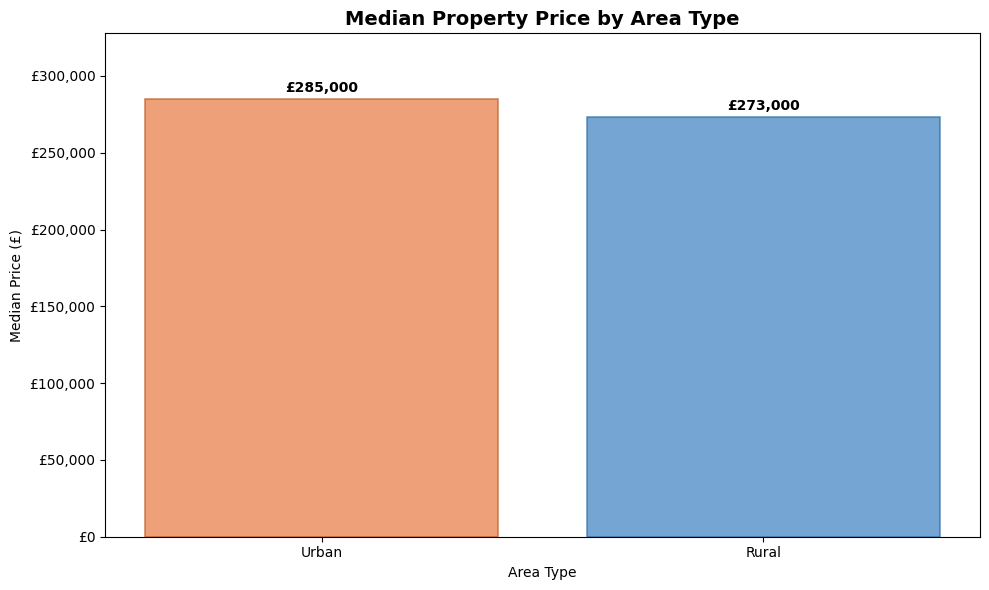

In [14]:
median_prices = df_merged.groupby("area_type")["price"].median().reset_index()
median_prices.columns = ["area_type", "median_price"]
median_prices = median_prices.sort_values("median_price", ascending=False)

# Match the histogram colors
area_colors = {
    "Urban": "#E87A3F",  # orange
    "Rural": "#3A7FC1",  #
}
colors = [area_colors.get(a, "#CCCCCC") for a in median_prices["area_type"]]
edge_colors = ["#2A6FA8" if c == "#3A7FC1" else "#C05A1F" for c in colors]

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(
    median_prices["area_type"],
    median_prices["median_price"],
    color=colors,
    edgecolor=edge_colors,
    linewidth=1.2,
    alpha=0.7,  # match the histogram transparency
)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height * 1.01,
        f"£{height:,.0f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
    )

ax.set_title("Median Property Price by Area Type", fontsize=14, fontweight="bold")
ax.set_xlabel("Area Type")
ax.set_ylabel("Median Price (£)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"£{x:,.0f}"))
ax.set_ylim(0, median_prices["median_price"].max() * 1.15)

plt.tight_layout()
plt.show()

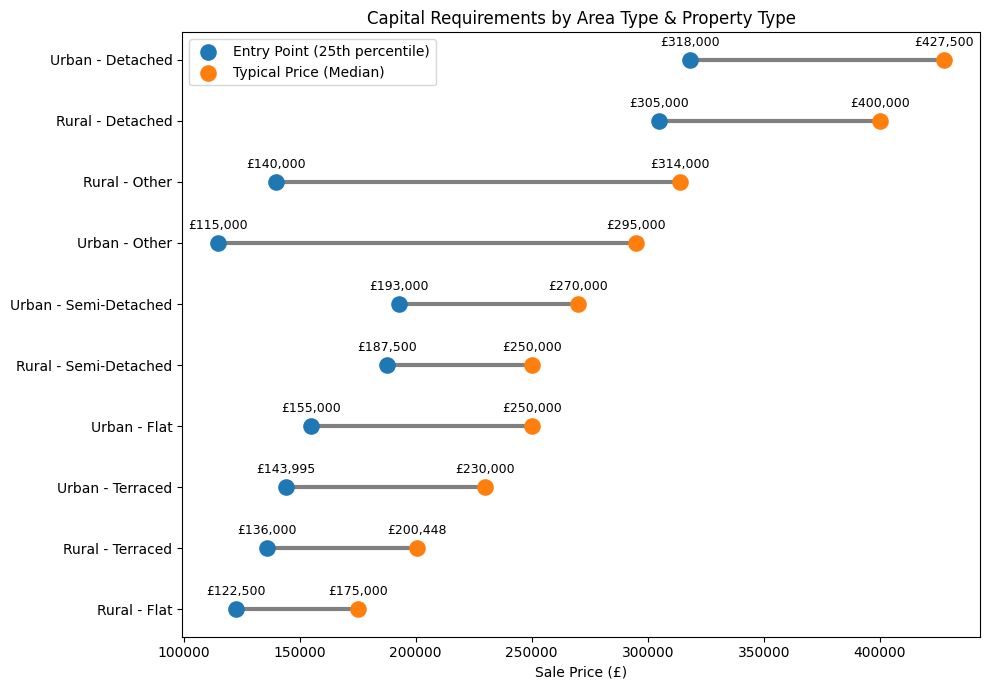

In [93]:
import matplotlib.pyplot as plt
import numpy as np

y_pos = np.arange(len(summary))

plt.figure(figsize=(10,7))

# connecting lines
for i in range(len(summary)):
    plt.plot(
        [summary["entry_price"].iloc[i], summary["median_price"].iloc[i]],
        [y_pos[i], y_pos[i]],
        color="gray",
        linewidth=3
    )

# entry points
plt.scatter(
    summary["entry_price"],
    y_pos,
    s=120,
    label="Entry Point (25th percentile)",
    zorder=3
)

# median points
plt.scatter(
    summary["median_price"],
    y_pos,
    s=120,
    label="Typical Price (Median)",
    zorder=3
)

# ---- BETTER LABEL POSITIONING ----
for i in range(len(summary)):

    entry = summary["entry_price"].iloc[i]
    median = summary["median_price"].iloc[i]

    # entry label
    plt.text(
        entry,
        y_pos[i] + 0.18,
        f"£{entry:,.0f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

    # median label
    plt.text(
        median,
        y_pos[i] + 0.18,
        f"£{median:,.0f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.yticks(y_pos, summary["area_property"])

plt.xlabel("Sale Price (£)")
plt.title("Capital Requirements by Area Type & Property Type")

plt.legend()
plt.tight_layout()
plt.show()

/tmp/ipykernel_275/63263690.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  median_prices = df_merged.groupby("old_new")["price"].median().reset_index()


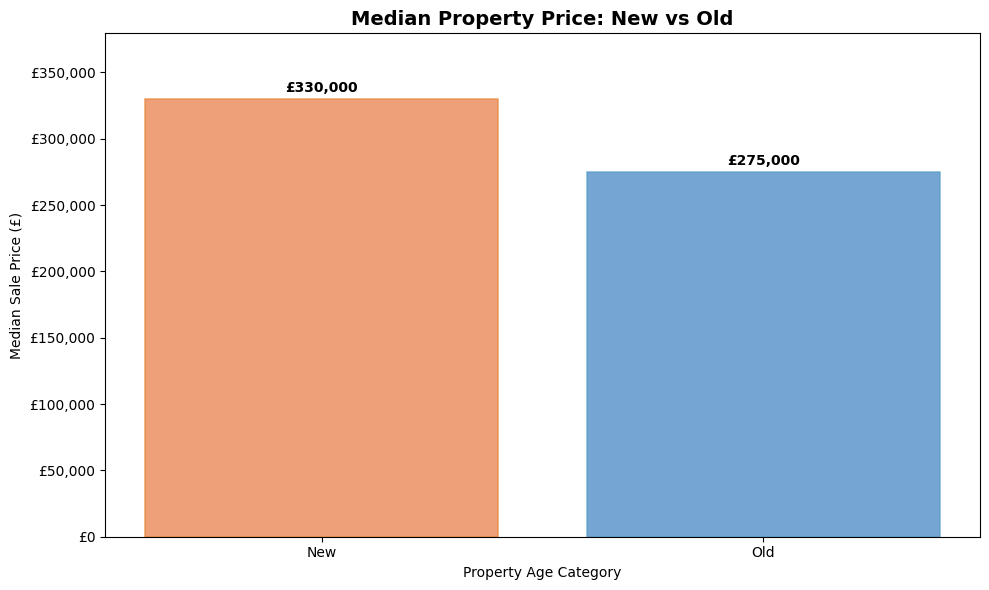

In [184]:
median_prices = df_merged.groupby("old_new")["price"].median().reset_index()
median_prices.columns = ["old_new", "median_price"]
median_prices["label"] = median_prices["old_new"].map({"N": "Old", "Y": "New"})
median_prices = median_prices.sort_values("median_price", ascending=False)

age_colors = {"New": "#E87A3F", "Old": "#3A7FC1"}
edge_colors_map = {"New": "#E8883A", "Old": "#5A9EC9"}

colors = [age_colors[l] for l in median_prices["label"]]
edges = [edge_colors_map[l] for l in median_prices["label"]]

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(
    median_prices["label"],
    median_prices["median_price"],
    color=colors,
    edgecolor=edges,
    linewidth=1.2,
    alpha=0.7,
)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height * 1.01,
        f"£{height:,.0f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
    )

ax.set_title("Median Property Price: New vs Old", fontsize=14, fontweight="bold")
ax.set_xlabel("Property Age Category")
ax.set_ylabel("Median Sale Price (£)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"£{x:,.0f}"))
ax.set_ylim(0, median_prices["median_price"].max() * 1.15)

plt.tight_layout()
plt.show()

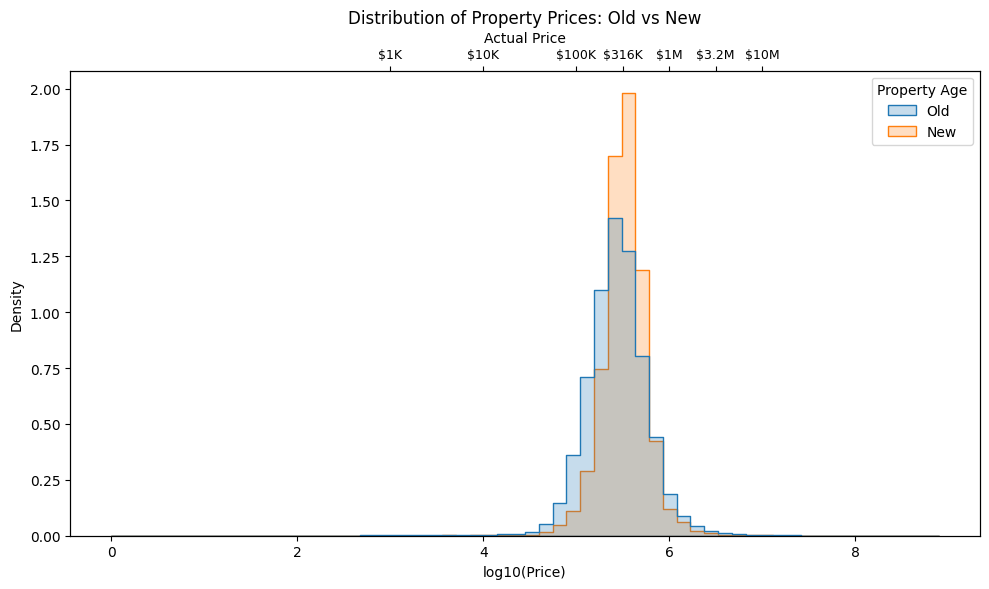

In [186]:
fig, ax = plt.subplots(figsize=(10, 6))
sample = df_merged
sample["log_price"] = np.log10(sample["price"])

sns.histplot(
    data=sample,
    x="log_price",
    hue="old_new",
    bins=60,
    element="step",
    stat="density",
    common_norm=False,
    ax=ax,
)

ax.set_title("Distribution of Property Prices: Old vs New")
ax.set_xlabel("log10(Price)")
ax.set_ylabel("Density")
legend = ax.get_legend()
legend.set_title("Property Age")
for t, label in zip(legend.texts, ["Old", "New"]):
    t.set_text(label)
# Add actual price labels on top x-axis
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
ax2.set_xticks([3, 4, 5, 5.5, 6, 6.5, 7])
ax2.set_xticklabels(["$1K", "$10K", "$100K", "$316K", "$1M", "$3.2M", "$10M"], fontsize=9)
ax2.set_xlabel("Actual Price", fontsize=10)

plt.tight_layout()
plt.show()

# Archive

In [45]:
# months = ["December 2024"] + [f"{i} 2025" for i in ["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"]] + ['January 2026']
# dataframes = []
# columns = ['transaction_id', 'price', 'date_of_transfer', 'postcode',
#     'property_type', 'old_new', 'duration', 'paon', 'saon',
#     'street', 'locality', 'town_city', 'district', 'county',
#     'ppd_category_type', 'record_status']

# for month in months:
#   filenames = f'/content/drive/MyDrive/Internship BCC/Project/{month} data.csv'
#   sub_df = pd.read_csv(filenames, header=None, names=columns)

#   sub_df['month'] = month
#   dataframes.append(sub_df)

# df = pd.concat(dataframes, axis=0, ignore_index=True)

# df.head()